# Omar Khader's PS2 - Where is Rocky?


In [96]:
import numpy as np # for all the math and array stuff we need
import cv2 # opencv for messing with images and finding keypoints
import matplotlib.pyplot as plt # for making cool plots and visualizations
import os # for file operations like loading images
import time # to time how long our algorithm takes
from typing import Tuple, List # just some type hints to make code clearer

import random
np.random.seed(42) # set random seed so results are consistent
random.seed(42)


## Understanding the Problem
We gotta find Rocky in test images using keypoint matching. Rocky can be:
- Anywhere in the image (sneaky little guy)
- Rotated between -90 and 90 degrees (spinning around like crazy)
- Different sizes (height up to image height - he's flexible!)
- Partially occluded (less than 30% - still gotta find him though)

We're using SIFT keypoints and manual matching to track him down!


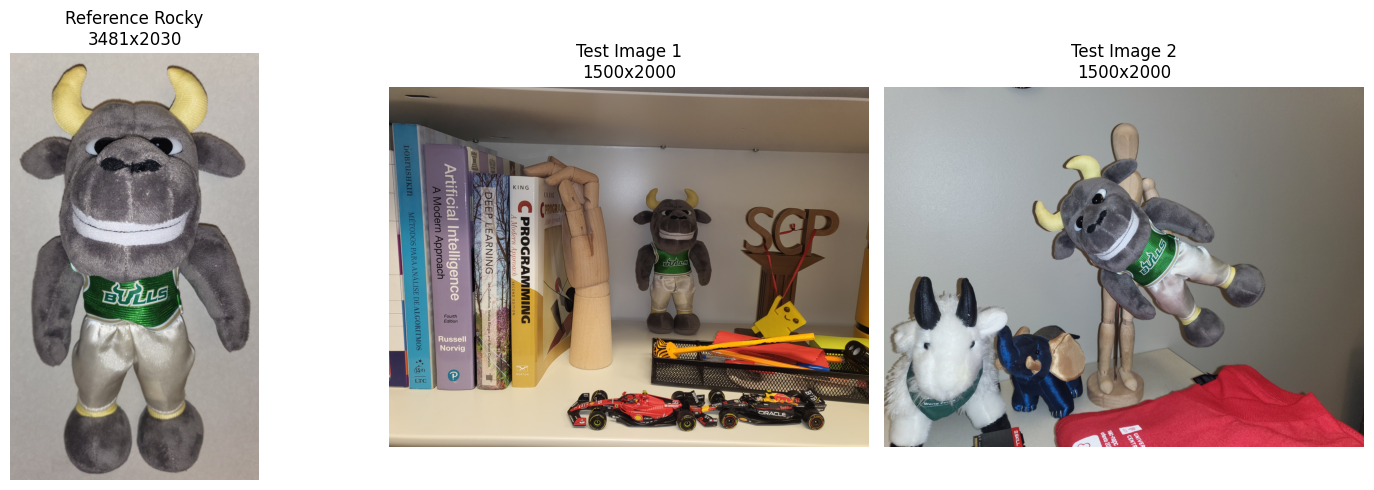

In [97]:
# let's load up the reference image and some test images to see what we're working with
reference_path = 'tests/reference.png' # where Rocky is hanging out in the reference pic
test_path_1 = 'tests/1.png' # first test image to search
test_path_2 = 'tests/2.png' # second test image to check

# load the images
ref_img = cv2.imread(reference_path, cv2.IMREAD_COLOR) # grab the reference image in color
test_img_1 = cv2.imread(test_path_1, cv2.IMREAD_COLOR) # load first test image
test_img_2 = cv2.imread(test_path_2, cv2.IMREAD_COLOR) # load second test image

# convert from BGR to RGB for matplotlib (opencv loads in BGR, matplotlib wants RGB)
ref_img_rgb = cv2.cvtColor(ref_img, cv2.COLOR_BGR2RGB) # flip colors for matplotlib
test_img_1_rgb = cv2.cvtColor(test_img_1, cv2.COLOR_BGR2RGB) # convert test 1
test_img_2_rgb = cv2.cvtColor(test_img_2, cv2.COLOR_BGR2RGB) # convert test 2

# display images
fig, axes = plt.subplots(1, 3, figsize=(15, 5)) # create 3 subplots side by side

axes[0].imshow(ref_img_rgb) # show reference image
axes[0].set_title(f'Reference Rocky\n{ref_img.shape[0]}x{ref_img.shape[1]}') # show dimensions in title
axes[0].axis('off') # hide axes

axes[1].imshow(test_img_1_rgb) # show test image 1
axes[1].set_title(f'Test Image 1\n{test_img_1.shape[0]}x{test_img_1.shape[1]}') # show dimensions
axes[1].axis('off') # hide axes

axes[2].imshow(test_img_2_rgb) # show test image 2
axes[2].set_title(f'Test Image 2\n{test_img_2.shape[0]}x{test_img_2.shape[1]}') # show dimensions
axes[2].axis('off') # hide axes

plt.tight_layout() # adjust spacing
plt.show() # display the figure


## Step 1: Keypoint Detection with SIFT
SIFT (Scale-Invariant Feature Transform) finds keypoints that are invariant to scale and rotation. Perfect for finding Rocky at different sizes and orientations!


Detecting keypoints...
Found 3000 keypoints in reference image
Found 3000 keypoints in test image 1
First 5 keypoints attributes: [((1616.2784423828125, 1253.1104736328125), 3.751758337020874, 7.290496826171875), ((1714.7481689453125, 1207.791748046875), 4.963890552520752, 101.267822265625), ((404.6819763183594, 663.6636962890625), 2.860114574432373, 229.82369995117188), ((1276.9847412109375, 1112.911376953125), 2.4708831310272217, 359.2496337890625), ((469.5914306640625, 709.3092651367188), 2.6350479125976562, 275.8158874511719)]
Keypoint sizes - min: 1.800, max: 155.938, avg: 4.07
Number of keypoints with size 0: 0
Reference keypoints: 3000 filtered (size >= 1.0) out of 3000 total
Test keypoints: 3000 filtered (size >= 1.0) out of 3000 total
Using 3000 keypoints for current visualization
Valid keypoints with size > 0: 3000 out of 3000 total


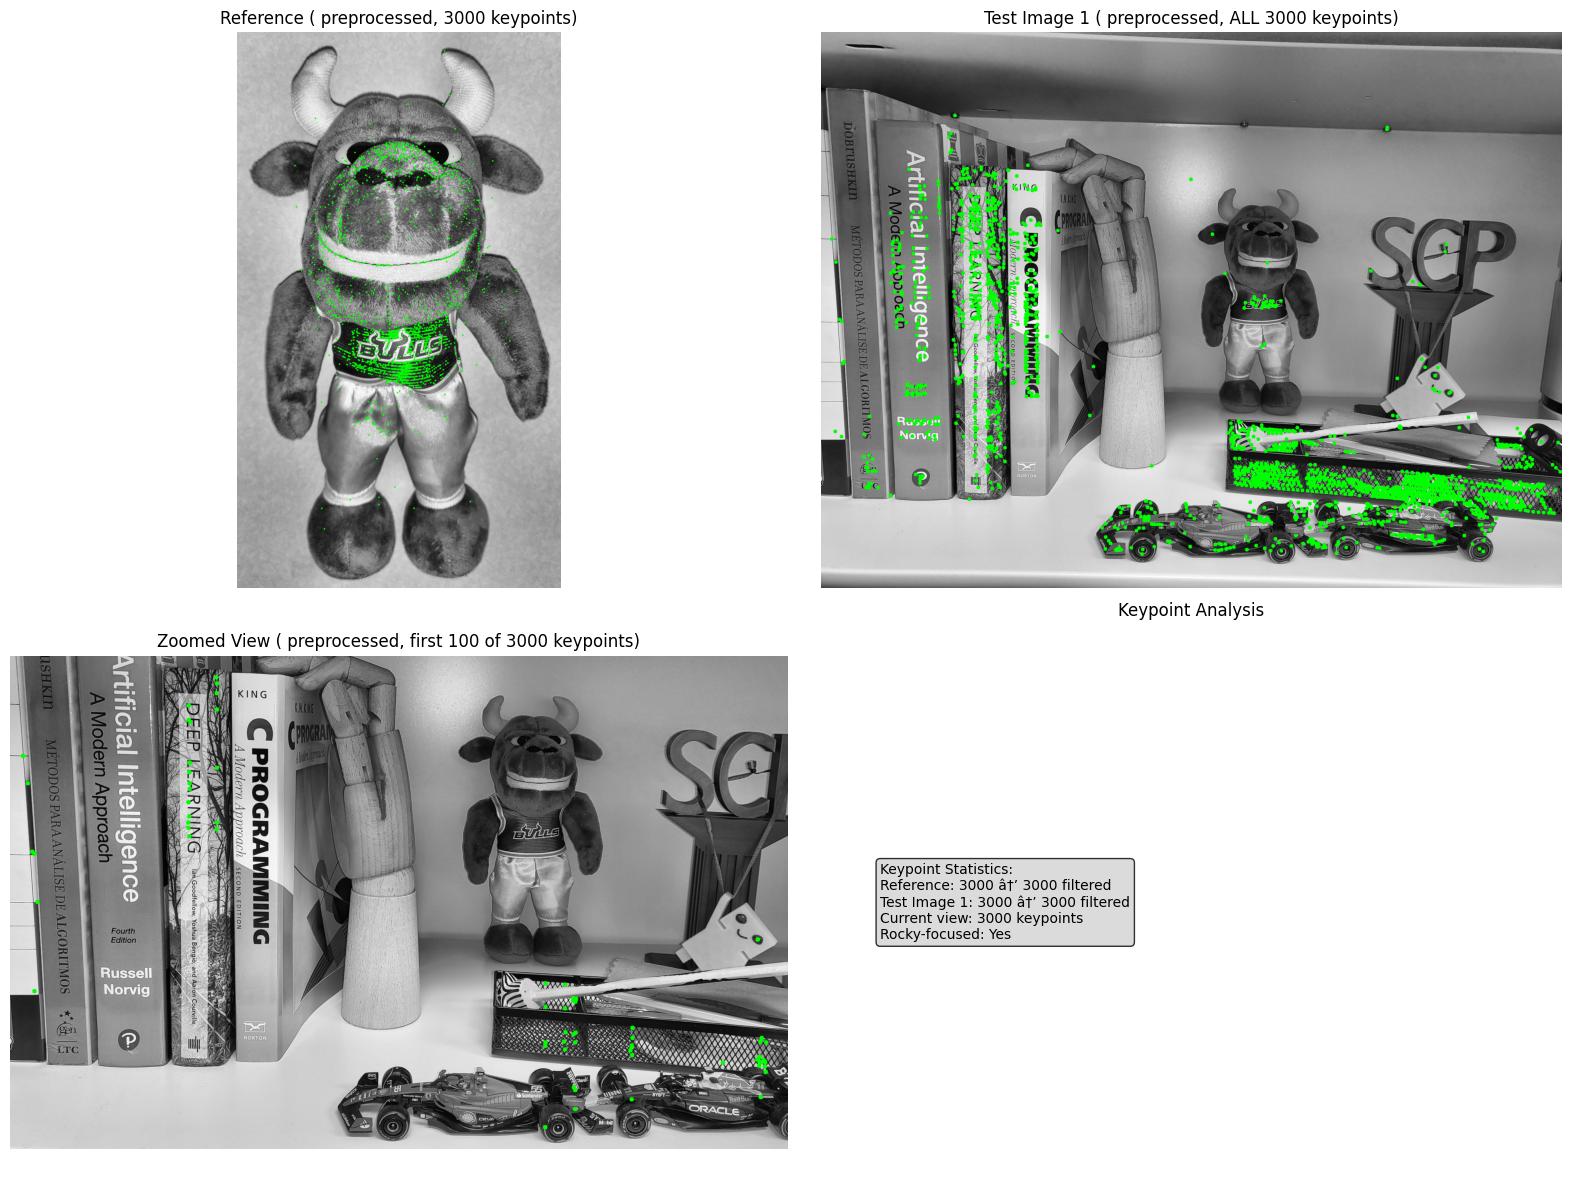

In [98]:
# create optimized SIFT detector for Rocky detection
sift = cv2.SIFT_create(
    nfeatures=3000,           # Maximum features to detect
    nOctaveLayers=3,          # Layers per octave
    contrastThreshold=0.04,   # Lower = more features (was default 0.04)
    edgeThreshold=10,         # Higher = fewer edge features (was default 10)
    sigma=1.6                 # Gaussian sigma (was default 1.6)
)

# function to detect keypoints and compute descriptors with Rocky-focused preprocessing
def detect_and_describe(image, focus_on_rocky=False):
    """
    Detect keypoints and compute descriptors for an image
    We're keeping it simple - no weird masking that might miss stuff
    """
    # convert to grayscale cuz SIFT likes that
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # apply some contrast enhancement to help find more features
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8,8))
    gray = clahe.apply(gray)

    # try SIFT first, fall back to ORB if not available
    try:
        sift = cv2.SIFT_create(nfeatures=3000) # grab lots of keypoints
        keypoints, descriptors = sift.detectAndCompute(gray, None)
        metric = "L2" # distance metric for SIFT
    except AttributeError:
        # if SIFT's not available, use ORB as backup
        orb = cv2.ORB_create(nfeatures=2000)
        keypoints, descriptors = orb.detectAndCompute(gray, None)
        metric = "Hamming" # different distance metric for ORB

    # return keypoints, descriptors, metric type, and the preprocessed image
    return keypoints, descriptors, metric, gray


# let's find those keypoints in both images
print("Detecting keypoints...")

# get keypoints for reference image (standard processing)
ref_kp, ref_desc, ref_metric, ref_gray = detect_and_describe(ref_img) # find keypoints in reference
print(f"Found {len(ref_kp)} keypoints in reference image") # how many did we get?

# get keypoints for test image 1 â€” only if it's available
test1_kp, test1_desc, test1_metric, test1_gray = [], None, None, None
if 'test_img_1' in locals():
    test1_kp, test1_desc, test1_metric, test1_gray = detect_and_describe(test_img_1) # find keypoints in test 1
    print(f"Found {len(test1_kp)} keypoints in test image 1")
else:
    print("Test image 1 not in scope (skipping test image detection)")

# filter keypoints for display (consistent filtering for both images)
min_size_for_display = 1.0 # minimum size to be visible

# filter reference image keypoints (size only)
ref_sized_kp = [kp for kp in ref_kp if kp.size >= min_size_for_display]

# draw keypoints on preprocessed grayscale image (what SIFT actually sees)
ref_with_kp = cv2.cvtColor(ref_gray, cv2.COLOR_GRAY2RGB) # convert grayscale to RGB for display
for kp in ref_sized_kp: # draw filtered reference keypoints as bright green circles
    x, y = int(kp.pt[0]), int(kp.pt[1]) # get coordinates
    cv2.circle(ref_with_kp, (x, y), 5, (0, 255, 0), -1) # bright green dot r 5

# draw keypoints with different approaches to see what's working 
if len(test1_kp) > 0:
    print(f"First 5 keypoints attributes: {[(kp.pt, kp.size, kp.angle) for kp in test1_kp[:5]]}") # debug keypoint info
    sizes = [kp.size for kp in test1_kp] # get sizes of ALL keypoints
    # guard for empties (though len>0)
    print(f"Keypoint sizes - min: {min(sizes):.3f}, max: {max(sizes):.3f}, avg: {sum(sizes)/len(sizes):.2f}") # debug sizes
    print(f"Number of keypoints with size 0: {sum(1 for s in sizes if s == 0)}") # count zero-size keypoints
else:
    print("No test keypoints to analyze (sizes).")

# filter test image keypoints size only, same as reference
test_sized_kp = [kp for kp in test1_kp if kp.size >= min_size_for_display] if 'test_img_1' in locals() and len(test1_kp) > 0 else []

# use appropriate filtered keypoints for visualization
sized_kp = test_sized_kp if ('test_img_1' in locals() and len(test_sized_kp) > 0) else ref_sized_kp

print(f"Reference keypoints: {len(ref_sized_kp)} filtered (size >= {min_size_for_display}) out of {len(ref_kp)} total")
if 'test_img_1' in locals():
    print(f"Test keypoints: {len(test_sized_kp)} filtered (size >= {min_size_for_display}) out of {len(test1_kp)} total")
print(f"Using {len(sized_kp)} keypoints for current visualization") # show count

# show preprocessed grayscale image (what SIFT actually sees) with keypoints overlaid
if 'test_img_1_rgb' in locals() and test1_gray is not None:
    test1_manual_kp = cv2.cvtColor(test1_gray, cv2.COLOR_GRAY2RGB) # convert grayscale to RGB for display
    for kp in sized_kp: # plot ALL keypoints as bright green circles
        x, y = int(kp.pt[0]), int(kp.pt[1]) # get coordinates
        # draw a circle (bright green) at keypoint location
        cv2.circle(test1_manual_kp, (x, y), 5, (0, 255, 0), -1) # bright green dot (radius 5)
else:
    test1_manual_kp = None

# create a zoomed-in view of a keypoint-rich area for better visibility
if 'test_img_1_rgb' in locals() and len(sized_kp) > 20:
    # get coordinates of first 100 keypoints (or all if less than 100)
    num_kp_for_zoom = min(100, len(sized_kp))
    kp_coords = [(int(kp.pt[0]), int(kp.pt[1])) for kp in sized_kp[:num_kp_for_zoom]]
    # calculate bounding box safely
    if len(kp_coords) > 0:
        min_x = min(coord[0] for coord in kp_coords)
        max_x = max(coord[0] for coord in kp_coords)
        min_y = min(coord[1] for coord in kp_coords)
        max_y = max(coord[1] for coord in kp_coords)

        # add some padding
        pad = 50
        zoom_x1 = max(0, min_x - pad)
        zoom_y1 = max(0, min_y - pad)
        zoom_x2 = min(test_img_1_rgb.shape[1], max_x + pad)
        zoom_y2 = min(test_img_1_rgb.shape[0], max_y + pad)

        # extract zoomed region from preprocessed grayscale image
        zoomed_region = test1_gray[zoom_y1:zoom_y2, zoom_x1:zoom_x2]
        zoomed_region_rgb = cv2.cvtColor(zoomed_region, cv2.COLOR_GRAY2RGB) # convert to RGB for display

        # draw keypoints on zoomed preprocessed region
        test1_zoomed_kp = zoomed_region_rgb.copy()
        for kp in sized_kp[:num_kp_for_zoom]:
            x, y = int(kp.pt[0]) - zoom_x1, int(kp.pt[1]) - zoom_y1
            if 0 <= x < test1_zoomed_kp.shape[1] and 0 <= y < test1_zoomed_kp.shape[0]:
                # draw circle (bright green) at keypoint location
                cv2.circle(test1_zoomed_kp, (x, y), 5, (0, 255, 0), -1) # bright green dot (radius 5)
    else:
        test1_zoomed_kp = None
else:
    test1_zoomed_kp = None

# check if keypoints have valid size and angle information (for debugging)
if len(test1_kp) > 0:
    valid_kp = [kp for kp in test1_kp if kp.size > 0] # filter keypoints with valid size
    print(f"Valid keypoints with size > 0: {len(valid_kp)} out of {len(test1_kp)} total") # debug info

# display
fig, axes = plt.subplots(2, 2, figsize=(16, 12)) # 2 rows, 2 columns

# top row - full image views
axes[0, 0].imshow(ref_with_kp) # show reference preprocessed image with keypoints
axes[0, 0].set_title(f'Reference ( preprocessed, {len(ref_sized_kp)} keypoints)') # title
axes[0, 0].axis('off') # hide axes

if test1_manual_kp is not None:
    axes[0, 1].imshow(test1_manual_kp) # show test preprocessed image with keypoints
    axes[0, 1].set_title(f'Test Image 1 ( preprocessed, ALL {len(sized_kp)} keypoints)') # title
else:
    axes[0, 1].text(0.5, 0.5, 'Test image view not available', transform=axes[0, 1].transAxes,
                    ha='center', va='center', fontsize=12)
axes[0, 1].axis('off') # hide axes

# bottom row - zoomed view and statistics
if test1_zoomed_kp is not None:
    axes[1, 0].imshow(test1_zoomed_kp) # show zoomed keypoints
    axes[1, 0].set_title(f'Zoomed View ( preprocessed, first {num_kp_for_zoom} of {len(sized_kp)} keypoints)') # title
else:
    axes[1, 0].text(0.5, 0.5, 'Zoomed view not available', transform=axes[1, 0].transAxes,
                    ha='center', va='center', fontsize=12) # placeholder
axes[1, 0].axis('off') # hide axes

# show keypoint statistics
current_image = "Test Image 1" if 'test_img_1' in locals() else "Reference"
stats_text = (
    f"Keypoint Statistics:\n"
    f"Reference: {len(ref_kp)} â†’ {len(ref_sized_kp)} filtered\n"
    f"Test Image 1: {len(test1_kp)} â†’ {len(test_sized_kp)} filtered\n"
    f"Current view: {len(sized_kp)} keypoints\n"
    f"Rocky-focused: {'Yes' if 'test_img_1' in locals() else 'No'}"
)
axes[1, 1].text(0.1, 0.5, stats_text, transform=axes[1, 1].transAxes,
               fontsize=10, verticalalignment='center',
               bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8)) # statistics
axes[1, 1].set_title('Keypoint Analysis') # title
axes[1, 1].axis('off') # hide axes

plt.tight_layout() # adjust spacing
plt.show() # display


## Step 2: Manual Keypoint Matching
We can see for example that in test image 1, sift sticks to the metal pencil holder thing because there are many corners and edges.
We need to match keypoints between reference and test images ourselves no OpenCV matching allowed.
We should use the ratio test: a match is good if the best match is significantly better than the second best.


In [99]:
# manual matching function - doing it ourselves!
def manual_match_features(desc1, desc2, ratio_threshold=0.72):
    """
    Manually match SIFT descriptors using ratio test
    desc1: descriptors from reference image
    desc2: descriptors from test image
    ratio_threshold: threshold for ratio test (default 0.72)
    """
    matches = [] # list to store good matches

    # for each descriptor in reference image
    for i, d1 in enumerate(desc1):
        # calculate distances to all descriptors in test image
        # using vectorized operations for speed
        dists = np.sum((desc2 - d1)**2, axis=1)  # squared euclidean distances

        # find two best matches
        sorted_indices = np.argpartition(dists, 2)[:2]  # get indices of 2 smallest
        sorted_dists = dists[sorted_indices]
        sorted_dists.sort()  # ensure they're sorted

        # apply ratio test
        if len(sorted_dists) >= 2 and sorted_dists[1] > 0:
            ratio = np.sqrt(sorted_dists[0]) / np.sqrt(sorted_dists[1])  # use actual distances for ratio
            if ratio < ratio_threshold:
                best_idx = np.argmin(dists)  # index of best match
                matches.append((i, best_idx, np.sqrt(sorted_dists[0])))  # store match

    return matches

# match features between reference and test image 1
print("Matching features... this might take a moment as we're doing it manually!") # warning about time
start_time = time.time() # start timer
matches = manual_match_features(ref_desc, test1_desc, ratio_threshold=0.72) # find matches with standard ratio
end_time = time.time() # end timer
print(f"Found {len(matches)} good matches in {end_time - start_time:.2f} seconds") # report results


Matching features... this might take a moment as we're doing it manually!
Found 27 good matches in 0.47 seconds


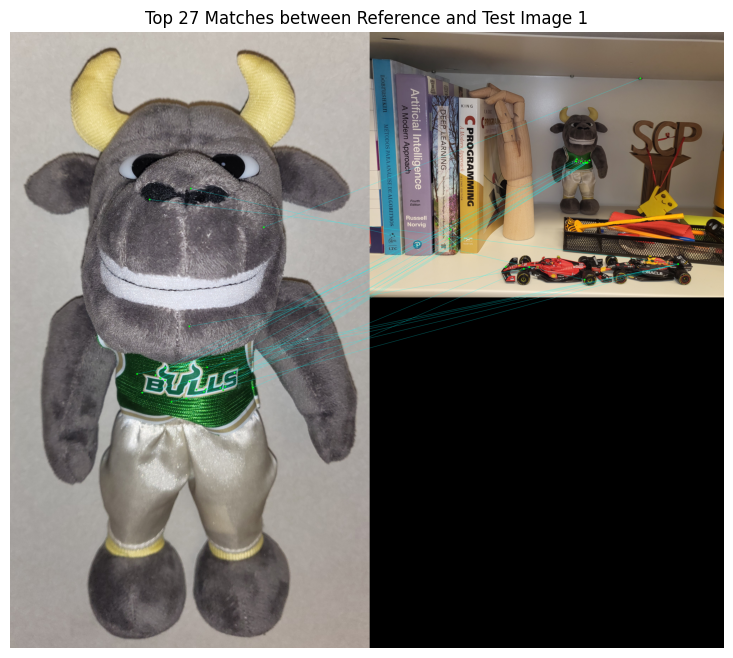

In [100]:
# visualize the matches
def draw_matches(img1, kp1, img2, kp2, matches, num_matches=50):
    """
    Draw matches between two images
    """
    # get dimensions
    h1, w1 = img1.shape[:2] # height and width of image 1
    h2, w2 = img2.shape[:2] # height and width of image 2

    # create output image (side by side)
    out = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8) # big enough for both
    out[:h1, :w1] = img1 # place image 1 on left
    out[:h2, w1:] = img2 # place image 2 on right

    # draw only the best matches
    matches_sorted = sorted(matches, key=lambda x: x[2])[:num_matches] # sort by distance and take best

    # draw lines for each match
    for ref_idx, test_idx, dist in matches_sorted:
        # get keypoint coordinates
        pt1 = kp1[ref_idx].pt # point in reference image
        pt2 = kp2[test_idx].pt # point in test image

        # convert to integer coordinates
        x1, y1 = int(pt1[0]), int(pt1[1]) # reference point
        x2, y2 = int(pt2[0] + w1), int(pt2[1]) # test point (shifted by width of img1)

        # draw circles at keypoints
        cv2.circle(out, (x1, y1), 5, (0, 255, 0), -1) # green circle on reference
        cv2.circle(out, (x2, y2), 5, (0, 255, 0), -1) # green circle on test

        # draw line connecting them
        cv2.line(out, (x1, y1), (x2, y2), (0, 255, 255), 1) # yellow line

    return out

# draw matches
matches_img = draw_matches(ref_img_rgb, ref_kp, test_img_1_rgb, test1_kp, matches, num_matches=min(30, len(matches)))

plt.figure(figsize=(15, 8)) # large figure
plt.imshow(matches_img) # show matches
plt.title(f'Top {min(30, len(matches))} Matches between Reference and Test Image 1')
plt.axis('off') # hide axes
plt.show() # display


## Step 3: Find Transformation Using RANSAC
We need to find the affine transformation between reference and test image. Since some matches might be wrong as we can see. we call those outliers, we'll use RANSAC to find a robust transformation.


In [101]:
# function to find the best affine transformation using RANSAC
def find_transformation_ransac(kp1, kp2, matches, num_iterations=2000, threshold=4.0):
    """
    Find affine transformation using RANSAC
    kp1: keypoints from reference image
    kp2: keypoints from test image
    matches: list of matches
    num_iterations: RANSAC iterations
    threshold: inlier threshold in pixels
    """
    if len(matches) < 3: # need at least 3 matches for affine
        return None, []

    best_transform = None # best transformation matrix found
    best_inliers = [] # indices of inlier matches

    # convert matches to point arrays
    src_pts = np.float32([kp1[m[0]].pt for m in matches])
    dst_pts = np.float32([kp2[m[1]].pt for m in matches])

    # rANSAC iterations
    for _ in range(num_iterations):
        # randomly select 3 matches (minimum for affine)
        if len(matches) < 3:
            continue
        idx = np.random.choice(len(matches), 3, replace=False) # random 3 indices

        # get the 3 point pairs
        src_subset = src_pts[idx] # 3 source points
        dst_subset = dst_pts[idx] # 3 destination points

        # compute affine transformation
        try:
            M = cv2.getAffineTransform(src_subset, dst_subset) # get 2x3 affine matrix
        except:
            continue # skip if transformation fails

        # test all matches with this transformation
        inliers = [] # store inlier indices
        for i, (src_pt, dst_pt) in enumerate(zip(src_pts, dst_pts)):
            # transform source point
            src_homo = np.array([src_pt[0], src_pt[1], 1]) # homogeneous coordinates
            dst_pred = M @ src_homo # apply transformation

            # calculate error
            error = np.sqrt((dst_pred[0] - dst_pt[0])**2 + (dst_pred[1] - dst_pt[1])**2) # euclidean distance

            # check if inlier
            if error < threshold:
                inliers.append(i) # add to inliers

        # update best if more inliers
        if len(inliers) > len(best_inliers):
            best_inliers = inliers # update best inliers
            best_transform = M # update best transformation

    return best_transform, best_inliers

# find transformation
print("Finding transformation with RANSAC...") # status
transform, inliers = find_transformation_ransac(ref_kp, test1_kp, matches) # run RANSAC
print(f"Found transformation with {len(inliers)} inliers out of {len(matches)} matches") # report results

if transform is not None:
    print(f"Transformation matrix:") # show matrix
    print(transform) # print the 2x3 affine matrix


Finding transformation with RANSAC...
Found transformation with 11 inliers out of 27 matches
Transformation matrix:
[[ 1.85470363e-01 -2.53519967e-02  1.05475914e+03]
 [ 3.83952293e-03  1.40696501e-01  4.51198478e+02]]


## Step 4: Compute Bounding Box from Transformation
Once we have the transformation, we need to:
1. Transform the corners of the reference image
2. Find the oriented bounding box
3. Extract center, height, and finally angle


In [102]:
# function to compute oriented bounding box from transformation
def compute_bounding_box(ref_shape, transform_matrix):
    """
    Compute oriented bounding box parameters from transformation
    ref_shape: (height, width) of reference image
    transform_matrix: 2x3 affine transformation matrix
    Returns: (center_x, center_y, height, angle)
    """
    h, w = ref_shape # reference image dimensions

    # define corners of reference image
    corners = np.array([
        [0, 0, 1],      # top-left
        [w-1, 0, 1],    # top-right
        [w-1, h-1, 1],  # bottom-right
        [0, h-1, 1]     # bottom-left
    ]).T # transpose for matrix multiplication

    # transform corners to test image coordinates
    transformed_corners = transform_matrix @ corners # apply transformation
    transformed_corners = transformed_corners.T # transpose back

    # find center
    center_x = np.mean(transformed_corners[:, 0]) # average x coordinates
    center_y = np.mean(transformed_corners[:, 1]) # average y coordinates

    # calculate height (distance between top and bottom edges)
    top_center = (transformed_corners[0] + transformed_corners[1]) / 2 # midpoint of top edge
    bottom_center = (transformed_corners[2] + transformed_corners[3]) / 2 # midpoint of bottom edge
    height = np.sqrt((bottom_center[0] - top_center[0])**2 + (bottom_center[1] - top_center[1])**2) # distance

    # calculate angle (from vertical, clockwise positive)
    # vector from top to bottom center
    dx = bottom_center[0] - top_center[0]
    dy = bottom_center[1] - top_center[1]

    # angle from vertical (positive y-axis points down in image coordinates)
    # atan2(dx, dy) gives angle from vertical
    angle_rad = np.arctan2(dx, dy)
    angle_deg = np.degrees(angle_rad)

    # normalize angle to [0, 360)
    angle_deg = angle_deg % 360

    return int(center_x), int(center_y), int(height), int(angle_deg)

# test on our example
if transform is not None:
    bbox = compute_bounding_box(ref_img.shape[:2], transform) # compute bounding box
    print(f"Bounding box: center=({bbox[0]}, {bbox[1]}), height={bbox[2]}, angle={bbox[3]}Â°") # show results


Bounding box: center=(1198, 699), height=497, angle=349Â°


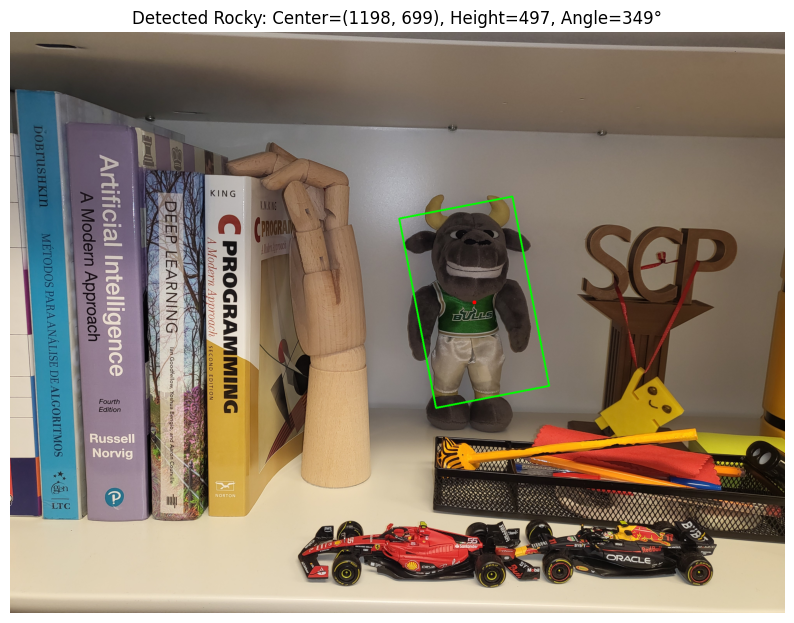

In [108]:
# visualize the bounding box
def draw_oriented_bbox(image, cx, cy, h, angle_deg):
    """
    Draw an oriented bounding box on the image
    """
    # width is 60% of height as per requirements
    w = int(0.6 * h) # calculate width

    # convert angle to radians
    angle_rad = np.radians(angle_deg) # convert to radians

    # calculate corners of the oriented rectangle
    # start with axis-aligned rectangle centered at origin
    corners = np.array([
        [-w/2, -h/2],  # top-left
        [w/2, -h/2],   # top-right
        [w/2, h/2],    # bottom-right
        [-w/2, h/2]    # bottom-left
    ])

    # rotation matrix
    cos_a = np.cos(angle_rad) # cosine of angle
    sin_a = np.sin(angle_rad) # sine of angle
    rot_matrix = np.array([[cos_a, -sin_a], [sin_a, cos_a]]) # 2D rotation matrix

    # rotate and translate corners
    rotated_corners = corners @ rot_matrix.T # rotate corners
    final_corners = rotated_corners + np.array([cx, cy]) # translate to center

    # convert to integer coordinates
    final_corners = final_corners.astype(np.int32) # convert to int

    # draw the bounding box
    output = image.copy() # copy image
    cv2.polylines(output, [final_corners], True, (0, 255, 0), 3) # draw green box
    cv2.circle(output, (cx, cy), 5, (255, 0, 0), -1) # draw blue center

    return output

# draw bounding box on test image
if transform is not None:
    test_with_bbox = draw_oriented_bbox(test_img_1_rgb, bbox[0], bbox[1], bbox[2], bbox[3]) # draw bbox

    plt.figure(figsize=(10, 8)) # create figure
    plt.imshow(test_with_bbox) # show image with bbox
    plt.title(f'Detected Rocky: Center=({bbox[0]}, {bbox[1]}), Height={bbox[2]}, Angle={bbox[3]}°') # title
    plt.axis('off') # hide axes
    plt.show() # display


## Step 5: Complete Pipeline
Now let's put everything together into a complete function that finds Rocky in any image.


In [104]:
# main function to find Rocky in an image
def find_rocky(reference_img, test_img, ratio_threshold=0.72, ransac_iterations=2000, ransac_threshold=4.0):
    """
    Find Rocky in a test image using keypoint matching
    reference_img: reference image of Rocky
    test_img: test image to search in
    Returns: (center_x, center_y, height, angle) or None if not found
    """
    # step 1: Detect keypoints and descriptors
    ref_kp, ref_desc, _, _ = detect_and_describe(reference_img) # get reference keypoints
    test_kp, test_desc, _, _ = detect_and_describe(test_img) # get test keypoints

    # check if we have enough keypoints
    if ref_desc is None or test_desc is None or len(ref_desc) < 10 or len(test_desc) < 10:
        print("Not enough keypoints detected") # warning message
        return None

    # step 2: Match features manually
    matches = manual_match_features(ref_desc, test_desc, ratio_threshold) # find matches

    # check if we have enough matches
    if len(matches) < 8:
        print(f"Not enough matches found: {len(matches)}") # warning message
        return None

    # step 3: Find transformation using RANSAC
    transform, inliers = find_transformation_ransac(ref_kp, test_kp, matches, ransac_iterations, ransac_threshold) # get transformation

    # check if transformation was found
    if transform is None or len(inliers) < 5:
        print(f"Could not find valid transformation. Inliers: {len(inliers)}") # warning message
        return None

    # step 4: Compute bounding box
    bbox = compute_bounding_box(reference_img.shape[:2], transform) # get bounding box parameters

    return bbox

# test the complete pipeline
ref_img = cv2.imread('tests/reference.png', cv2.IMREAD_COLOR) # load reference
test_img = cv2.imread('tests/1.png', cv2.IMREAD_COLOR) # load test image

print("Finding Rocky in test image 1...") # status
start_time = time.time() # start timer
result = find_rocky(ref_img, test_img) # find Rocky
end_time = time.time() # end timer

if result:
    print(f"Found Rocky at: X={result[0]}, Y={result[1]}, H={result[2]}, A={result[3]}") # show results
    print(f"Time taken: {end_time - start_time:.2f} seconds") # show time
else:
    print("Failed to find Rocky") # failure message


Finding Rocky in test image 1...
Found Rocky at: X=1199, Y=699, H=497, A=349
Time taken: 2.30 seconds


## Step 6: IoU Calculation and Testing on All Images
Now we need to:
1. Load ground truth annotations
2. Calculate IoU between our predictions and ground truth
3. Test on all images and compute average IoU


In [105]:
# function to calculate iou between two oriented bounding boxes
def calculate_iou(img_size, cx1, cy1, h1, a1, cx2, cy2, h2, a2):
    """
    calculate iou between two oriented bounding boxes
    Based on the provided grading script
    """
    # convert angles to radians
    a1_rad = np.radians(a1) # angle 1 in radians
    a2_rad = np.radians(a2) # angle 2 in radians

    # width is 60% of height
    w1 = 0.6 * h1 # width of box 1
    w2 = 0.6 * h2 # width of box 2

    # function to get corners of oriented rectangle
    def get_corners(cx, cy, w, h, angle):
        # rectangle corners before rotation (centered at origin)
        corners = np.array([
            [-w/2, -h/2],  # top-left
            [w/2, -h/2],   # top-right
            [w/2, h/2],    # bottom-right
            [-w/2, h/2]    # bottom-left
        ])

        # rotation matrix
        cos_a = np.cos(angle) # cosine
        sin_a = np.sin(angle) # sine
        rot = np.array([[cos_a, -sin_a], [sin_a, cos_a]]) # rotation matrix

        # rotate and translate
        rotated = corners @ rot.T # rotate
        translated = rotated + np.array([cx, cy]) # translate to center

        return translated

    # get corners of both boxes
    corners1 = get_corners(cx1, cy1, w1, h1, a1_rad) # corners of box 1
    corners2 = get_corners(cx2, cy2, w2, h2, a2_rad) # corners of box 2

    # create masks for both boxes
    mask1 = np.zeros(img_size, dtype=np.uint8) # mask for box 1
    mask2 = np.zeros(img_size, dtype=np.uint8) # mask for box 2

    # fill polygons
    cv2.fillPoly(mask1, [corners1.astype(np.int32)], 255) # fill box 1
    cv2.fillPoly(mask2, [corners2.astype(np.int32)], 255) # fill box 2

    # calculate intersection and union
    intersection = np.logical_and(mask1, mask2).sum() # count pixels in both
    union = np.logical_or(mask1, mask2).sum() # count pixels in either

    # calculate iou
    if union == 0:
        return 0.0 # avoid division by zero

    iou = intersection / union # intersection over union
    return iou

# load ground truth for comparison
def load_ground_truth(txt_path):
    """
    Load ground truth from txt file
    """
    with open(txt_path, 'r') as f:
        line = f.readline().strip() # read first line
        if line:
            values = line.split() # split by spaces
            return int(values[0]), int(values[1]), int(values[2]), int(values[3]) # X, Y, H, A
    return None

# test with ground truth
gt = load_ground_truth('tests/1.txt') # load ground truth for image 1
if gt and result:
    iou = calculate_iou((1500, 2000), result[0], result[1], result[2], result[3],
                        gt[0], gt[1], gt[2], gt[3]) # calculate IoU
    print(f"\nGround truth: X={gt[0]}, Y={gt[1]}, H={gt[2]}, A={gt[3]}") # show ground truth
    print(f"Our result:   X={result[0]}, Y={result[1]}, H={result[2]}, A={result[3]}") # show our result
    print(f"IoU: {iou:.3f}") # show IoU score



Ground truth: X=1186, Y=725, H=615, A=0
Our result:   X=1199, Y=699, H=497, A=349
IoU: 0.643


## Step 7: Test on All Images and Calculate Average IoU
Let's run our algorithm on all test images and see how well we perform!


In [106]:
# test on all images
def test_all_images():
    """
    Test Rocky detection on all test images and calculate average IoU
    """
    # load reference image once
    ref_img = cv2.imread('tests/reference.png', cv2.IMREAD_COLOR) # load reference

    # \find all test images
    test_images = [] # list to store test image numbers
    for i in range(1, 15): # check images 1-14
        if os.path.exists(f'tests/{i}.png') and os.path.exists(f'tests/{i}.txt'):
            test_images.append(i) # add if both image and ground truth exist

    print(f"Found {len(test_images)} test images") # show how many we found

    # store results
    results = [] # list to store all results
    ious = [] # list to store IoU scores

    # process each test image
    for img_num in test_images:
        print(f"\n--- Processing image {img_num} ---") # separator

        # load test image
        test_path = f'tests/{img_num}.png' # path to test image
        test_img = cv2.imread(test_path, cv2.IMREAD_COLOR) # load test image

        # load ground truth
        gt_path = f'tests/{img_num}.txt' # path to ground truth
        gt = load_ground_truth(gt_path) # load ground truth

        # find Rocky
        start_time = time.time() # start timer
        result = find_rocky(ref_img, test_img) # find Rocky
        end_time = time.time() # end timer

        # calculate IoU if found
        if result and gt:
            iou = calculate_iou((1500, 2000), result[0], result[1], result[2], result[3],
            gt[0], gt[1], gt[2], gt[3]) # calculate IoU
            ious.append(iou) # add to list

            print(f"Result: X={result[0]}, Y={result[1]}, H={result[2]}, A={result[3]}") # show result
            print(f"Ground: X={gt[0]}, Y={gt[1]}, H={gt[2]}, A={gt[3]}") # show ground truth
            print(f"IoU: {iou:.3f}, Time: {end_time - start_time:.2f}s") # show IoU and time

            results.append({
                'image': img_num,
                'result': result,
                'ground_truth': gt,
                'iou': iou,
                'time': end_time - start_time
            }) # store all info
        else:
            print("Failed to find Rocky!") # failure message
            ious.append(0.0) # IoU is 0 if not found

    # calculate average IoU
    avg_iou = np.mean(ious) if ious else 0.0 # average IoU
    print(f"\n=== FINAL RESULTS ===") # header
    print(f"Average IoU: {avg_iou:.3f}") # show average
    print(f"Successfully detected: {len([i for i in ious if i > 0])}/{len(test_images)}") # show success rate

    # show grade based on average IoU
    if avg_iou >= 0.7:
        print("Grade: 90/90 points (Full credit!)") # full credit
    elif avg_iou >= 0.5:
        print("Grade: 75/90 points") # partial credit
    elif avg_iou >= 0.2:
        print("Grade: 45/90 points") # minimal credit
    else:
        print("Grade: 0/90 points") # no credit
    # then return 
    return results, avg_iou

# run the test
print("Testing on all images... This will take a few minutes!") # warning
all_results, avg_iou = test_all_images() # run all tests


Testing on all images... This will take a few minutes!
Found 14 test images

--- Processing image 1 ---
Result: X=1198, Y=699, H=497, A=349
Ground: X=1186, Y=725, H=615, A=0
IoU: 0.644, Time: 2.23s

--- Processing image 2 ---
Result: X=1069, Y=675, H=939, A=50
Ground: X=1084, Y=686, H=1007, A=307
IoU: 0.444, Time: 2.48s

--- Processing image 3 ---
Result: X=1397, Y=1073, H=582, A=345
Ground: X=1397, Y=1096, H=596, A=3
IoU: 0.743, Time: 2.26s

--- Processing image 4 ---
Result: X=443, Y=566, H=448, A=354
Ground: X=457, Y=590, H=518, A=0
IoU: 0.736, Time: 2.20s

--- Processing image 5 ---
Result: X=501, Y=1009, H=746, A=351
Ground: X=494, Y=1053, H=584, A=354
IoU: 0.613, Time: 2.29s

--- Processing image 6 ---
Could not find valid transformation. Inliers: 4
Failed to find Rocky!

--- Processing image 7 ---
Result: X=1776, Y=415, H=548, A=356
Ground: X=1771, Y=423, H=725, A=2
IoU: 0.572, Time: 2.26s

--- Processing image 8 ---
Result: X=727, Y=777, H=1221, A=356
Ground: X=686, Y=766, H=12

## Step 8: Visualize Results
Let's visualize some of our successful detections!


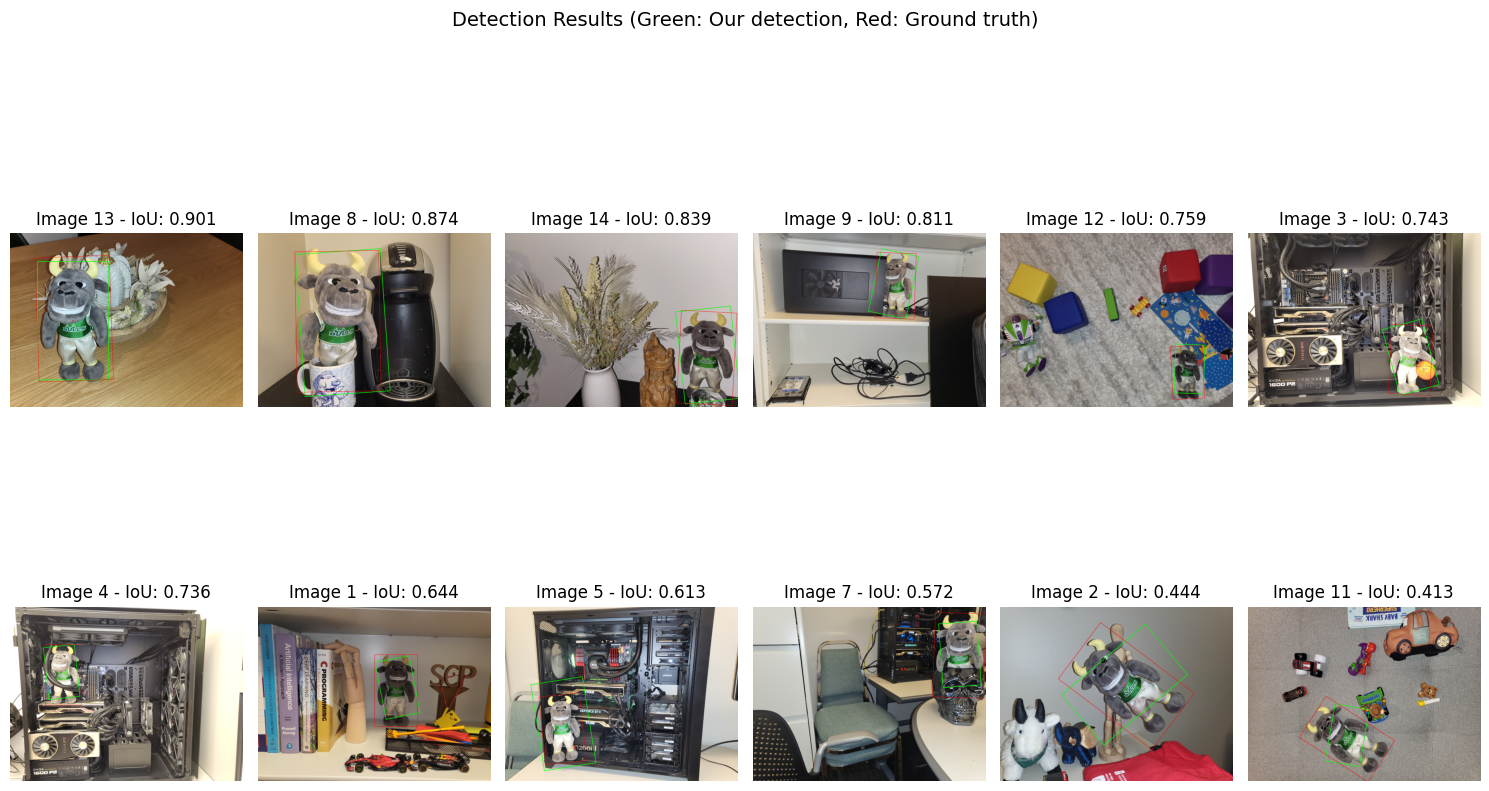

In [107]:
# visualize some results
def visualize_results(results, num_to_show=4):
    """
    Visualize detection results
    """
    # sort by IoU to show best results
    sorted_results = sorted(results, key=lambda x: x['iou'], reverse=True) # sort by IoU descending

    # create figure
    num_results = min(num_to_show, len(sorted_results)) # limit to available results
    fig, axes = plt.subplots(2, num_results//2, figsize=(15, 10)) # create subplots
    axes = axes.flatten() # flatten for easier indexing

    # show each result
    for i in range(num_results):
        res = sorted_results[i] # get result

        # load and draw on image
        img_path = f'tests/{res["image"]}.png' # path to image
        img = cv2.imread(img_path, cv2.IMREAD_COLOR) # load image
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # convert to RGB

        # draw our detection in green
        img_with_bbox = draw_oriented_bbox(img_rgb,
                                         res['result'][0], res['result'][1],
                                         res['result'][2], res['result'][3]) # draw our bbox

        # draw ground truth in red for comparison
        gt = res['ground_truth'] # ground truth
        h_gt = gt[2] # height
        w_gt = int(0.6 * h_gt) # width
        angle_rad = np.radians(gt[3]) # angle in radians

        # ground truth corners
        corners = np.array([
            [-w_gt/2, -h_gt/2],
            [w_gt/2, -h_gt/2],
            [w_gt/2, h_gt/2],
            [-w_gt/2, h_gt/2]
        ])

        # rotate and translate
        cos_a = np.cos(angle_rad) # cosine
        sin_a = np.sin(angle_rad) # sine
        rot = np.array([[cos_a, -sin_a], [sin_a, cos_a]]) # rotation matrix
        corners_rot = corners @ rot.T + np.array([gt[0], gt[1]]) # rotate and translate

        # draw ground truth in red
        cv2.polylines(img_with_bbox, [corners_rot.astype(np.int32)], True, (255, 0, 0), 2) # red box

        # show image
        axes[i].imshow(img_with_bbox) # display
        axes[i].set_title(f'Image {res["image"]} - IoU: {res["iou"]:.3f}') # title
        axes[i].axis('off') # hide axes

    plt.suptitle('Detection Results (Green: Our detection, Red: Ground truth)', fontsize=14) # main title
    plt.tight_layout() # adjust spacing
    plt.show() # display

# visualize best results
if all_results:
    visualize_results(all_results, num_to_show=12) # show 4 best results
